# Intro

* About the famous "attention" mechanism that has accelerated LLM performance
* A silly analogy to understand how this algorithm works
* The math of the basic attention algorithm
* How attention fits into the transformer block

$$ A = \sigma\Big(\frac{QK^T}{\sqrt{d_k}} + M\Big)VW_0 $$

* $A$ - Activations (adjustments)
* $Q$ - Query Matrix
* $K$ - Key Matrix
* $d_k$ - Dimensionality of $K$ Matrix
* $M$ - Time Maske
* $V$ - Value Matrix
* $W_0$ - Attention Outer Matrix

$$ Q = XW_Q $$
$$ K = XW_K $$
$$ V = XW_V $$

* $X$ - Token Embeddings Matrix
* $W_z$ - Relevant Weight Matrix (Special Attention Weight Matrices)

# Intuition

## Tokenization

Let's break it down. For reference:

$$ A = \sigma\Big(\frac{QK^T}{\sqrt{d_k}} + M\Big)VW_0 $$

Let's take an examplary sentence:

> Tim called Julia and laughed

For simplicity we treat each word as a single token.

**Tokenization**

As a recap ascribing token IDs to each word and then creating embedding matrix is a process that occurs before Language Model training, i.e. during Language Model training we already have ready embedding matrix.

First we give each token an Id

* Tim - 1234
* called - 5678
* Julia - 9101
* and - 1121
* laughed - 3141

```
token_ids = [1234, 5678, 9101, 1121, 3141]
```

Then we do embedding lookup with:

```
X = embedding_matrix[token_ids]
```

where:

```
X.shape = [5, embed_dim]
```

Let's assume embed_dim is 4, then X has following shape:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

embed_dim = 4
n_words   = 5

X = np.random.randn(n_words, embed_dim)
X

array([[-1.23104332,  1.40948999,  0.37042035, -0.13724441],
       [-0.01831983,  0.95986695, -0.51099726, -0.54539463],
       [ 1.00122595,  0.05155263, -1.4694672 ,  1.49866837],
       [ 2.61796141,  0.58127379, -0.91883516, -1.06195038],
       [-0.86008114, -0.17118914,  0.22513651, -0.00847246]])

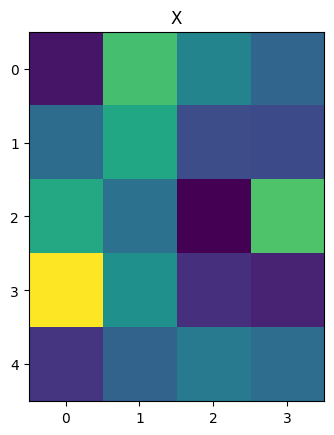

In [ ]:
def display_img(mat,name):
  plt.imshow(mat)
  plt.title(f'{name}')
  plt.show()

display_img(X, 'X')

## Matrix Initis

$$ Q = XW_Q $$
$$ K = XW_K $$
$$ V = XW_V $$

In [ ]:
head_dim = 2

WQ = np.random.randn(embed_dim, head_dim)
WV = np.random.randn(embed_dim, head_dim)
WK = np.random.randn(embed_dim, head_dim)

Q = X@WQ
K = X@WK
V = X@WV

We need to define head_dim which is desired column ambient space of $Q$, $K$, $V$, let's remember that $Q$, $K$, $V$ will have a dims of (n_words, head_dim) so the smaller head_dim the smaller representation we have of $Q$, $K$, $V$.

In [ ]:
print('Q:\n',Q,'\n')
print('K:\n',K,'\n')
print('V:\n',V,'\n')

Q:
 [[-1.28792207  0.5936034 ]
 [ 0.72479991 -1.10327482]
 [ 2.26959531  2.11742396]
 [ 2.09848455 -2.12942626]
 [-0.45219362 -0.14063789]] 

K:
 [[-2.50926599  1.2924661 ]
 [-1.18872536  0.14003983]
 [ 1.25610473 -2.9623339 ]
 [ 1.15360215 -0.23865652]
 [-0.51479627  0.21790021]] 

V:
 [[ 1.74871073 -0.75211979]
 [ 1.80353679 -2.049466  ]
 [-2.12477359 -0.60338883]
 [ 1.87189515 -5.74431039]
 [-0.07162465  1.6177796 ]] 



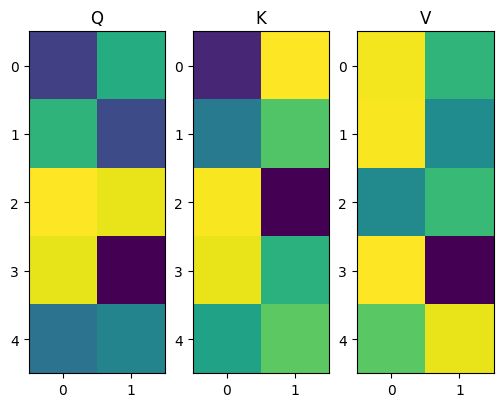

In [ ]:
_, ax = plt.subplots(1,3,figsize = (6,5))

ax[0].imshow(Q)
ax[0].set_title('Q')
ax[1].imshow(K)
ax[1].set_title('K')
ax[2].imshow(V)
ax[2].set_title('V')

plt.show()

## Importance of $QK^T$

$Q$ and $K$ are initially same matrices randomly selected. Authors in a paper explain that:

* Q = what the current token uses to match against other tokens
* K = what other tokens expose for matching
* V = the information that will actually be mixed and passed forward

For now let's just focus on $Q$ and $K$ though.

In [ ]:
Q

array([[-1.28792207,  0.5936034 ],
       [ 0.72479991, -1.10327482],
       [ 2.26959531,  2.11742396],
       [ 2.09848455, -2.12942626],
       [-0.45219362, -0.14063789]])

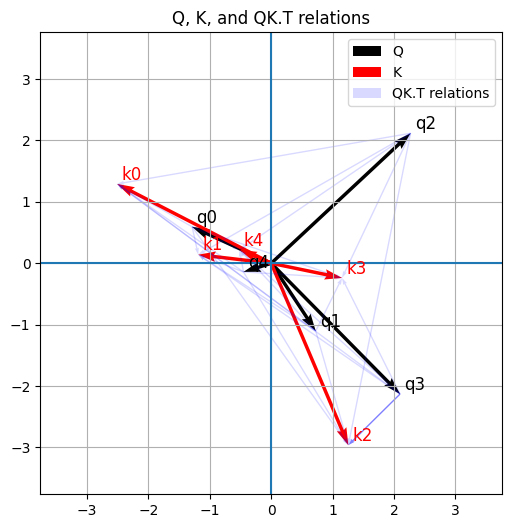

In [ ]:
plt.figure(figsize=(6, 6))

# Q vectors
plt.quiver(
    np.zeros(Q.shape[0]),
    np.zeros(Q.shape[0]),
    Q[:, 0],
    Q[:, 1],
    angles="xy",
    scale_units="xy",
    scale=1,
    label="Q"
)

# K vectors
plt.quiver(
    np.zeros(K.shape[0]),
    np.zeros(K.shape[0]),
    K[:, 0],
    K[:, 1],
    angles="xy",
    scale_units="xy",
    scale=1,
    label="K",
    color="r"
)

# qk.T = score matrix
S = Q @ K.T   # shape: [n_words, n_words]

# draw blue relation vectors:
# from q_i endpoint to k_j endpoint, thickness/alpha based on score
for i in range(Q.shape[0]):
    for j in range(K.shape[0]):
        start_x, start_y = Q[i, 0], Q[i, 1]
        dx = K[j, 0] - Q[i, 0]
        dy = K[j, 1] - Q[i, 1]

        score = S[i, j]

        plt.quiver(
            start_x,
            start_y,
            dx,
            dy,
            angles="xy",
            scale_units="xy",
            scale=1,
            color="b",
            alpha=0.15 + 0.35 * (score == S.max()),
            width=0.003
        )

# labels
for i, (x, y) in enumerate(Q):
    plt.text(x + 0.07, y + 0.07, f"q{i}", fontsize=12)

for i, (x, y) in enumerate(K):
    plt.text(x + 0.07, y + 0.07, f"k{i}", fontsize=12, color="r")

max_val = max(np.abs(Q).max(), np.abs(K).max()) + 0.8
plt.xlim(-max_val, max_val)
plt.ylim(-max_val, max_val)

plt.axhline(0)
plt.axvline(0)
plt.grid(True)
plt.gca().set_aspect("equal")
plt.title("Q, K, and QK.T relations")
plt.legend(["Q", "K", "QK.T relations"])
plt.show()

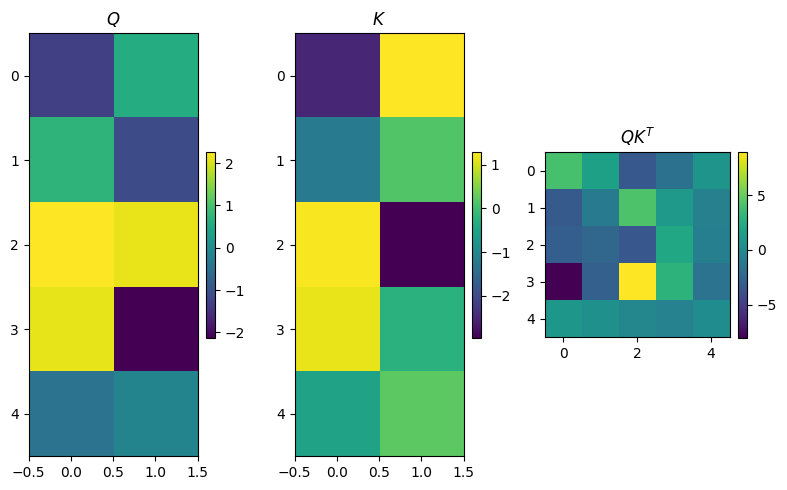

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(8, 5))

im0 = axs[0].imshow(Q)
axs[0].set_title('$Q$')
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

im1 = axs[1].imshow(K)
axs[1].set_title('$K$')
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

im2 = axs[2].imshow(Q @ K.T)
axs[2].set_title('$QK^T$')
fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

The first words in the sentence seem to have stronger relations with each other.
However, we should remember that we generated random embeddings, so these are not actual learned semantic relations.

So to conclude, we compute $QK^T$ to get raw attention scores between tokens. Each entry tells us how strongly the query representation of token i matches the key representation of token j. The larger the value, the stronger the raw attention relation between that token pair.

This equation $QK^T$ is in my opinion the core of modern LLMs. This simple algebraical dependency of matrix multiplication seems to be the core idea behind LLMs, and modern intelligence represenation. All the rest are helpers to make this equation $QK^T$ optimal.

## Division by $\sqrt{d_k}$

$d_k$ is the dimensionality of the key/query vectors inside one attention head.

In one head:

$$
Q, K \in \mathbb{R}^{n_{tokens} \times d_k}
$$

When we compute:

$$
QK^T
$$

each element is a dot product between one query vector and one key vector:

$$
(QK^T)_{ij} = q_i \cdot k_j
$$

Since this dot product sums over $d_k$ dimensions, its variance grows approximately proportionally to $d_k$:

$$
Var(q_i \cdot k_j) \approx d_k
$$

Therefore, we divide by $\sqrt{d_k}$:

$$
\frac{QK^T}{\sqrt{d_k}}
$$

because:

$$
Var\left(\frac{QK^T}{\sqrt{d_k}}\right)
=
\frac{Var(QK^T)}{d_k}
\approx 1
$$

This keeps the attention scores numerically stable before softmax.

In [ ]:
Q, K

(array([[-1.28792207,  0.5936034 ],
        [ 0.72479991, -1.10327482],
        [ 2.26959531,  2.11742396],
        [ 2.09848455, -2.12942626],
        [-0.45219362, -0.14063789]]),
 array([[-2.50926599,  1.2924661 ],
        [-1.18872536,  0.14003983],
        [ 1.25610473, -2.9623339 ],
        [ 1.15360215, -0.23865652],
        [-0.51479627,  0.21790021]]))

In [ ]:
qk = Q @ K.T
d_k = Q.shape[1]   # head_dim

scaled_scores = qk / np.sqrt(d_k)

print("head_dim / d_k:", d_k)

print("Var raw QK.T:", np.var(qk))
print("Var scaled QK.T:", np.var(scaled_scores))
print("Var raw / d_k:", np.var(qk) / d_k)

head_dim / d_k: 2
Var raw QK.T: 10.343383488909506
Var scaled QK.T: 5.171691744454751
Var raw / d_k: 5.171691744454753


Let's update qk based on d_k

In [ ]:
qk = qk / np.sqrt(d_k)

We can also run a Monte Carlo simulation with many random Q and K vectors to show that, under standard assumptions, the variance of the scaled dot product converges to approximately 1.

In [ ]:
import numpy as np

# Monte Carlo proof
n_trials = 100_000
head_dim = 64

# random q and k vectors with variance ~1
Q_ = np.random.randn(n_trials, head_dim)
K_ = np.random.randn(n_trials, head_dim)

# dot product q · k for each trial
scores = np.sum(Q_ * K_, axis=1)

scaled_scores = scores / np.sqrt(head_dim)

print("Var(Q elements):", np.var(Q_))
print("Var(K elements):", np.var(K_))
print("Expected Var(QK.T dot product) ≈ head_dim:", head_dim)
print("Observed Var(q · k):", np.var(scores))

print("\nAfter scaling by sqrt(head_dim):")
print("Expected variance ≈ 1")
print("Observed Var((q · k) / sqrt(head_dim)):", np.var(scaled_scores))

Var(Q elements): 1.0012874571507073
Var(K elements): 1.0000872062225576
Expected Var(QK.T dot product) ≈ head_dim: 64
Observed Var(q · k): 63.94587750974493

After scaling by sqrt(head_dim):
Expected variance ≈ 1
Observed Var((q · k) / sqrt(head_dim)): 0.9991543360897646


## +M

In GPT-like approach model CAN'T see the future, in textual time-series future are next words in the sentence, i.e. it's not something intangible. During training we want to force the model to predict next token based on previous ones so it will be able to generate tokens by itself. That's why we hide future tokens, predict their predicted versions, and eventually we compare using loss true tokens with predicted ones. That's how model learns. $+M$ is basically mask that hides future tokens.

We need negative infinity instead of 0, since later used softmax turns 0 into non-zero number, while negative infinity is changed into desired 0.

In [ ]:
M = np.tril(np.ones((qk.shape[0], qk.shape[1])))
M[M == 0] = -np.inf
M[M == 1] = 0

M

array([[  0., -inf, -inf, -inf, -inf],
       [  0.,   0., -inf, -inf, -inf],
       [  0.,   0.,   0., -inf, -inf],
       [  0.,   0.,   0.,   0., -inf],
       [  0.,   0.,   0.,   0.,   0.]])

Now when we have mask we can add it to qk. To clarify our `qk` will be equal to below formula for now, this is where we are now.

$$ qk = \frac{QK^T}{\sqrt{d_k}} + M$$

In [ ]:
qk = qk + M
qk

array([[ 2.8276856 ,        -inf,        -inf,        -inf,        -inf],
       [-2.29432184, -0.71848445,        -inf,        -inf,        -inf],
       [-2.09184786, -1.6980475 , -2.41948422,        -inf,        -inf],
       [-5.66948825, -1.9747557 ,  6.32435456,  2.07112832,        -inf],
       [ 0.67380514,  0.36616755, -0.10704618, -0.3451299 ,  0.14293638]])

Each row corresponds to a query time step, and each column corresponds to a key token.
So row 1 can attend only to token 1, row 2 can attend to tokens 1–2, row 3 to tokens 1–3, etc.
Future tokens receive -inf before softmax, so their attention weight becomes 0.

## $\sigma$

$$ attn = \sigma\Big(\frac{QK^T}{\sqrt{d_k}} + M\Big)$$

Currently our $qk$ is simply a matrix of logits of each token. We want to chenge them intro probabilities, that's why we're using Softmax.

In [ ]:
def softmax(m):
    exp_m = np.exp(m)
    return exp_m / np.sum(exp_m, axis=1, keepdims=True)

attn = softmax(qk)
attn

array([[1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [1.71385816e-01, 8.28614184e-01, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [3.12184931e-01, 4.62846796e-01, 2.24968273e-01, 0.00000000e+00,
        0.00000000e+00],
       [6.09396099e-06, 2.45189365e-04, 9.85733277e-01, 1.40154399e-02,
        0.00000000e+00],
       [3.18241207e-01, 2.33965114e-01, 1.45759541e-01, 1.14878445e-01,
        1.87155692e-01]])

Now, what is important `attn` is our attention. This matrix has probabilities of tokens being picked, each row sums to 1.

In [ ]:
attn.sum(axis = 1)

array([1., 1., 1., 1., 1.])

Now, lets see distributions of tokens.

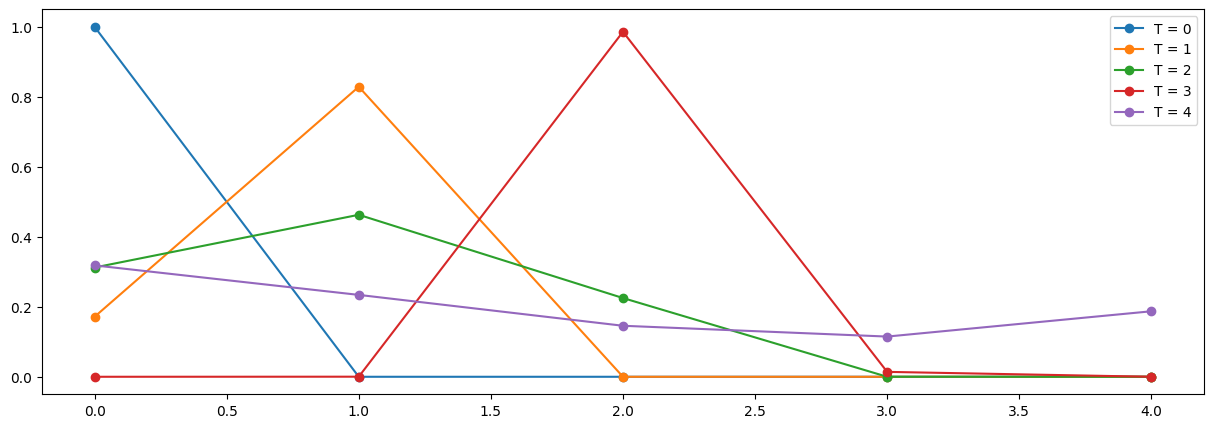

In [ ]:
plt.figure(figsize = (15,5))
for i, row in enumerate(attn):
  plt.plot(row, '-o', label = f'T = {i}')
plt.legend()
plt.show()

I found it weird at first that the latest tokens do not necessarily have the highest probabilities of being selected.

The reason is that `attn` is assembled from rows indexed by $t$ and columns indexed by $j$, where:

$$
score[t, j] = q_t \cdot k_j
$$

$$
attn[t, j] = softmax(score[t,:])[j]
$$

Therefore, `attn` represents probabilities of attention relations, not probabilities of tokens in isolation.

A given cell in the `attn` matrix is the probability that token $t$ attends to token $j$.

For example, suppose we look at row $t=4$, which corresponds to the token `"laughed"`.

If:

$$
attn[4, 0] = 0.10
$$

$$
attn[4, 1] = 0.15
$$

$$
attn[4, 2] = 0.60
$$

$$
attn[4, 3] = 0.10
$$

$$
attn[4, 4] = 0.05
$$

then token `"laughed"` attends mostly to token $j=2$, for example `"Julia"`.

This does not mean that `"Julia"` is globally the most important token. It only means that, from the perspective of token `"laughed"`, the query vector $q_4$ has the strongest relation with the key vector $k_2$.


In other words, row $t$ tells us how the current token distributes its attention across all allowed previous tokens $j$.

So the highest probability goes to the token with the strongest query-key relation, not necessarily to the closest or latest token.


## @V

Let:

$$ attn = \sigma\Big(\frac{QK^T}{\sqrt{d_k}} + M\Big)$$

$$ attnV =  \sigma\Big(\frac{QK^T}{\sqrt{d_k}} + M\Big)V$$

In [ ]:
attn.shape

(5, 5)

In [ ]:
V.shape

(5, 2)

Currently, attn has shape [T, T]. It stores attention probabilities between query positions t and key positions j.

To turn these relation probabilities into actual token representations, we multiply attn by V.

V has shape [T, d_head], so:

attn @ V = [T, T] @ [T, d_head] = [T, d_head]

Each output row is a weighted sum of value vectors.

In [ ]:
attnV = attn@V

In [ ]:
V.shape, attnV.shape

((5, 2), (5, 2))

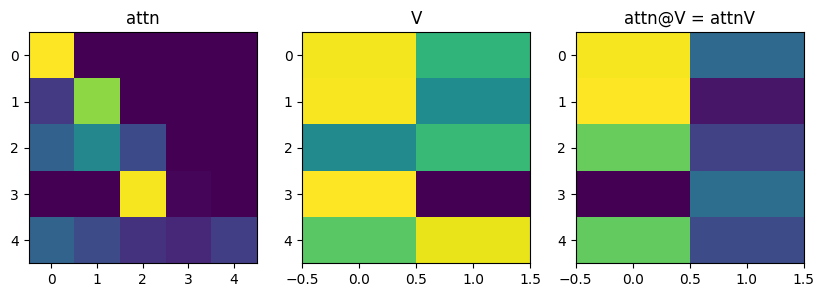

In [ ]:
_, axs = plt.subplots(1,3,figsize = (10,3))

axs[0].imshow(attn, aspect = 'auto')
axs[0].set_title('attn')

axs[1].imshow(V, aspect = 'auto')
axs[1].set_title('V')

axs[2].imshow(attnV, aspect = 'auto')
axs[2].set_title('attn@V = attnV')

plt.show()

attn tells us where to take information from; V contains the information being taken.

## $W_0$

Let:

$$ attnV =  \sigma\Big(\frac{QK^T}{\sqrt{d_k}} + M\Big)V$$

Since we transformed `attn` into `attnV`, we now have a representation in the `head_dim` output space.

Now we need to project it back to `embed_dim`.

$$
W_O \in \mathbb{R}^{head\_dim \times embed\_dim}
$$

Therefore:

$$
attnV W_O
$$

has shape:

$$
[T, head\_dim] @ [head\_dim, embed\_dim] = [T, embed\_dim]
$$

So the final output of the attention head is again represented in the original embedding dimension.

In [ ]:
# attn shape: [T, T]
# V shape:    [T, head_dim]
# W_O shape:  [head_dim, embed_dim]

attnV = attn @ V

embed_dim = X.shape[1]          # original embedding dimension
head_dim = V.shape[1]           # attention head dimension

W_O = np.random.randn(head_dim, embed_dim)

A = attnV @ W_O

print("attn shape:  ", attn.shape)
print("V shape:     ", V.shape)
print("attnV shape: ", attnV.shape)
print("W_O shape:   ", W_O.shape)
print("A shape:     ", A.shape)

attn shape:   (5, 5)
V shape:      (5, 2)
attnV shape:  (5, 2)
W_O shape:    (2, 4)
A shape:      (5, 4)


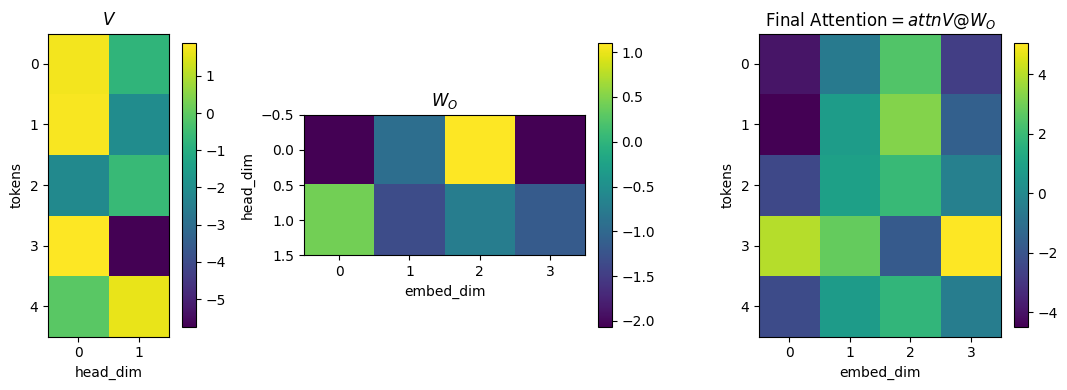

In [ ]:
# final attention output
A = attnV @ W_O

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

im0 = axs[0].imshow(V)
axs[0].set_title('$V$')
axs[0].set_xlabel('head_dim')
axs[0].set_ylabel('tokens')
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

im1 = axs[1].imshow(W_O)
axs[1].set_title('$W_O$')
axs[1].set_xlabel('embed_dim')
axs[1].set_ylabel('head_dim')
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

im2 = axs[2].imshow(A)
axs[2].set_title(r'$\mathrm{Final\ Attention} = attnV @ W_O$')
axs[2].set_xlabel('embed_dim')
axs[2].set_ylabel('tokens')
fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Manual Implementation

## Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import requests

## Params

In [ ]:
n_batch        = 4
n_embed        = 10
context_length = 8
vocab_size     = 40

## Data

In [ ]:
data = torch.randint(vocab_size, (n_batch, context_length)) # [batch, tokens]

## Inits

In [ ]:
# embedding matrix
embeddings = nn.Embedding(vocab_size, n_embed)

# create the q,k,v matrices
key   = nn.Linear(n_embed, n_embed, bias = False)
query = nn.Linear(n_embed, n_embed, bias = False)
value = nn.Linear(n_embed, n_embed, bias = False)

## Process the data

In [ ]:
# tokens to embeddings
x = embeddings(data)

# weight the data pre-attention
k = key(x)
q = query(x)
v = value(x)

In [ ]:
# print data sizes
print(f'      Data matrix: {data.shape}')
print(f'Embeddings matrix: {embeddings.weight.shape}')
print(f' Token embeddings: {x.shape}')

# sizes of matrices
print('')
print(f'          size of Q: {query.weight.shape}')
print(f'          size of K: {key.weight.shape}')
print(f'          size of V: {value.weight.shape}')

# print attention matrices sizes
print('')
print(f'          size of Q(x): {k.shape}')
print(f'          size of K(x): {q.shape}')
print(f'          size of V(x): {v.shape}')

      Data matrix: torch.Size([4, 8])
Embeddings matrix: torch.Size([40, 10])
 Token embeddings: torch.Size([4, 8, 10])

          size of Q: torch.Size([10, 10])
          size of K: torch.Size([10, 10])
          size of V: torch.Size([10, 10])

          size of Q(x): torch.Size([4, 8, 10])
          size of K(x): torch.Size([4, 8, 10])
          size of V(x): torch.Size([4, 8, 10])


## Self-Attention Implementation

In [ ]:
### manual implementation
# "cosine similarity" between query and keys
qk = q@k.transpose(-2,-1) # transpose non-batch dimensions -> change -2 dim with -1

# variance-scale the QK
qk_scaled = qk * 1/np.sqrt(n_embed)

# apply mask for future tokens

# M = 0    for past
# M = -ing for future
# we do + M with tril and -torch.ing
past_mask = torch.tril(torch.ones(n_batch, context_length, context_length))
qk_scaled[past_mask == 0] = -torch.inf # equivalent to adding a matrix of zeros/-infs

# softmaxify
qk_softmax = F.softmax(qk_scaled, dim = -1)

# and final attention mechanism
acts_manual = qk_softmax @ v

print(f'Shape of activations (manual): {acts_manual.shape}') # [batch. context, n_embed]

Shape of activations (manual): torch.Size([4, 8, 10])


# PyTorch Implementation

In [ ]:
acts_torch = F.scaled_dot_product_attention(q,k,v,is_causal=True)
print(f'Shape of activations (PyTorch): {acts_torch.shape}')

Shape of activations (PyTorch): torch.Size([4, 8, 10])


# Compare Implementations

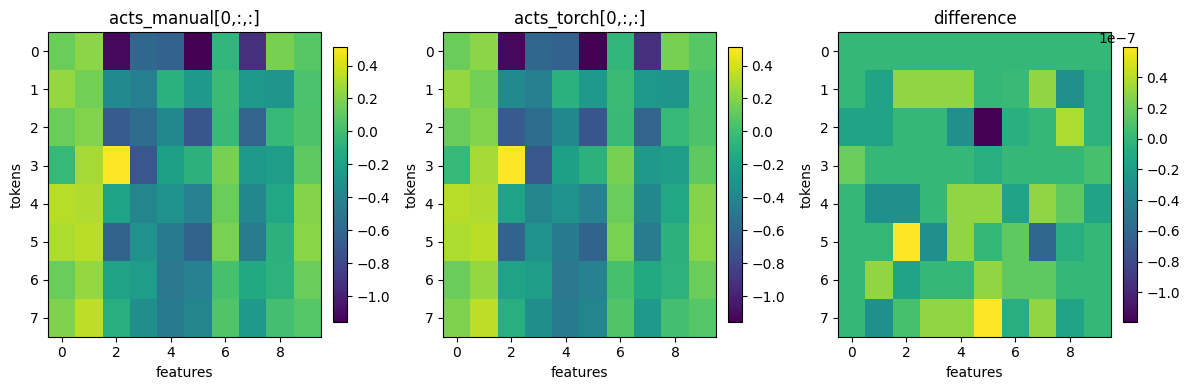

Exactly equal: False
All close: True
Max abs diff: 1.1920928955078125e-07


In [ ]:
# compare with imshow

manual = acts_manual[0, :, :].detach().cpu().numpy()
torch_out = acts_torch[0, :, :].detach().cpu().numpy()
diff = (acts_manual[0, :, :] - acts_torch[0, :, :]).detach().cpu().numpy()

fig, axs = plt.subplots(1, 3, figsize=(12, 4))

im0 = axs[0].imshow(manual, aspect="auto")
axs[0].set_title("acts_manual[0,:,:]")
axs[0].set_xlabel("features")
axs[0].set_ylabel("tokens")
fig.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)

im1 = axs[1].imshow(torch_out, aspect="auto")
axs[1].set_title("acts_torch[0,:,:]")
axs[1].set_xlabel("features")
axs[1].set_ylabel("tokens")
fig.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)

im2 = axs[2].imshow(diff, aspect="auto")
axs[2].set_title("difference")
axs[2].set_xlabel("features")
axs[2].set_ylabel("tokens")
fig.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("Exactly equal:", torch.equal(acts_torch, acts_manual))
print("All close:", torch.allclose(acts_torch, acts_manual))
print("Max abs diff:", torch.max(torch.abs(acts_manual - acts_torch)).item())

# GPU computation time

In [ ]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda', index=0)

Using bigger matrices

In [ ]:
n_batch = 64
n_embed = 1000
context_length = 2048
vocab_size = 50257

# matrices
data = torch.randint(vocab_size, (n_batch, context_length), dtype = torch.long, device = device)
embedding = nn.Embedding(vocab_size, n_embed, device = device)
key   = nn.Linear(n_embed, n_embed, bias = False, device = device)
query = nn.Linear(n_embed, n_embed, bias = False, device = device)
value = nn.Linear(n_embed, n_embed, bias = False, device = device)

x = embedding(data)
k = key(x)
q = query(x)
v = value(x)

Test

In [ ]:
import time

num_reps = 200

torch.cuda.synchronize() # synchronize the GPU&CPU. good for time-testing
start_time = time.time()

for _ in range(num_reps):
  qk = q@k.transpose(-2,-1) * (n_embed**-.5)
  past_mask = torch.tril(torch.ones(n_batch, context_length, context_length, device = device))
  qk[past_mask == 0] = -torch.inf
  qk = F.softmax(qk, dim = -1)
  activations_m = qk @ v
print(f'--- Manual:  {time.time()-start_time:.3f} sec')

torch.cuda.synchronize()
start_time = time.time()
for _ in range(num_reps):
  activations_p = F.scaled_dot_product_attention(q,k,v,is_causal = True)
print(f'--- PyTorch: {time.time()-start_time:.3f} sec')

--- Manual:  1.382 sec
--- PyTorch: 2.503 sec


PyTorch is slower than manual implementation. We can improve it though with optimizations.

In [ ]:
import torch._dynamo
SDPA_compiled = torch.compile(F.scaled_dot_product_attention)
torch.set_float32_matmul_precision('high')

Flash Attention: https://github.com/Dao-AILab/flash-attention

In [ ]:
import time

num_reps = 200

torch.cuda.synchronize() # synchronize the GPU&CPU. good for time-testing
start_time = time.time()

### MANUAL ###

for _ in range(num_reps):
  qk = q@k.transpose(-2,-1) * (n_embed**-.5)
  past_mask = torch.tril(torch.ones(n_batch, context_length, context_length, device = device))
  qk[past_mask == 0] = -torch.inf
  qk = F.softmax(qk, dim = -1)
  activations_m = qk @ v
print(f'--- Manual:  {time.time()-start_time:.3f} sec')

### DEFAULT TORCH ###

torch.cuda.synchronize()
start_time = time.time()
for _ in range(num_reps):
  activations_p = F.scaled_dot_product_attention(q,k,v,is_causal = True)
print(f'--- PyTorch: {time.time()-start_time:.3f} sec')

### OPTIMIZED TORCH ###

torch.cuda.synchronize()
start_time = time.time()
for _ in range(num_reps):
  activations0 = SDPA_compiled(q,k,v,is_causal = True)
print(f'--- Compiled: {time.time()-start_time:.3f} sec')

--- Manual:  1.388 sec
--- PyTorch: 2.497 sec
--- Compiled: 0.060 sec


Compiled PyTorch is way faster than manual one.

---

*Notebook is based on Mike X Cohen course. Notebook was modified.*